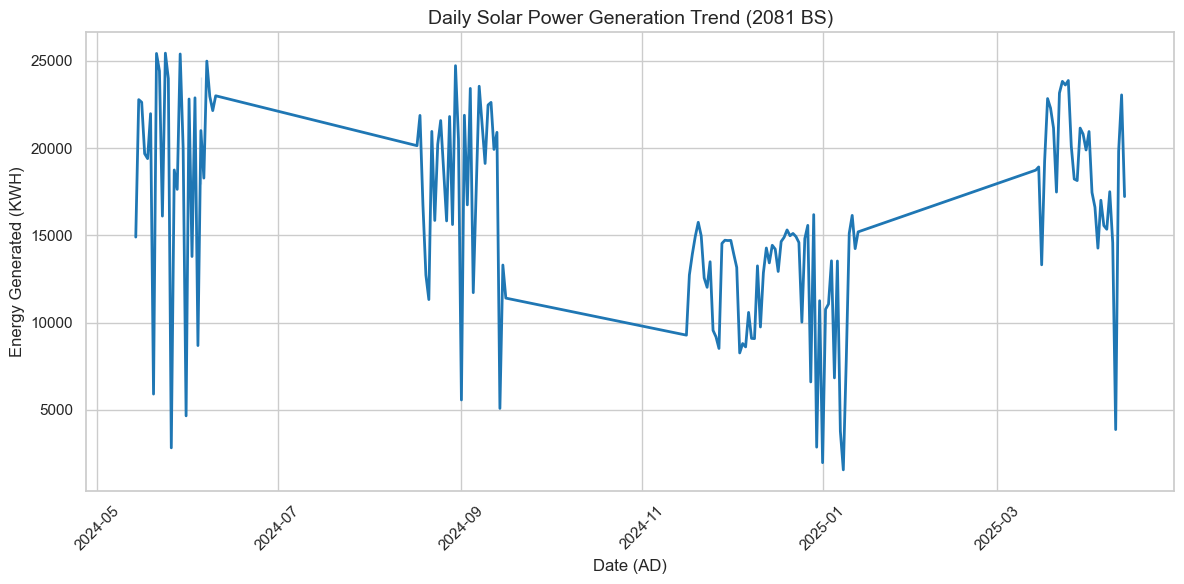

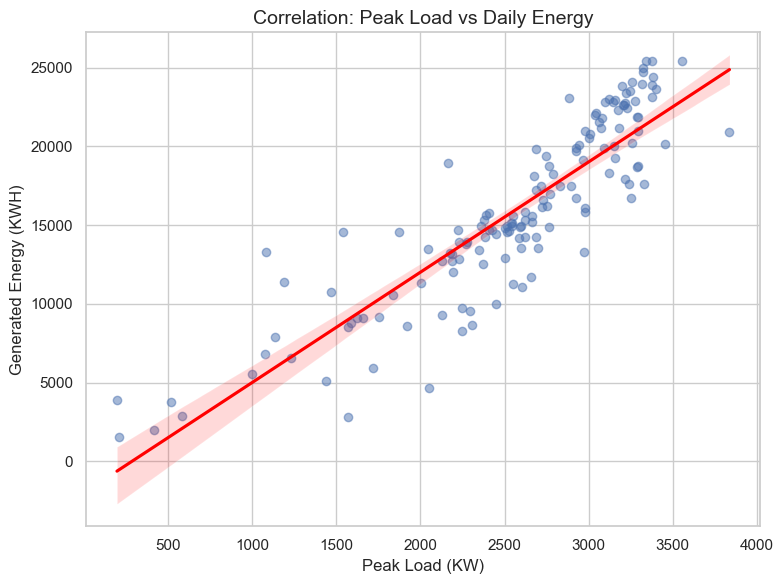

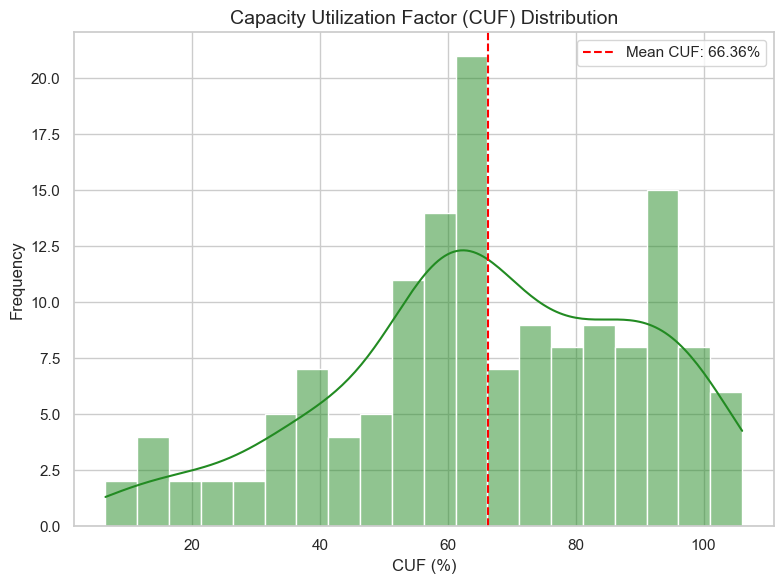

EDA Complete! Verified Columns: ['Date', 'Peak_load_KW', 'Generated_Energy_KWH', 'Date_AD', 'Specific_Yield', 'CUF_Percentage', 'Month', 'Day_of_Year', 'Day_of_Week']
Plots saved in: C:\Users\a2z\OneDrive\Desktop\solar_power_prediction\outputs\plots


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE_DIR = r'C:\Users\a2z\OneDrive\Desktop\solar_power_prediction'
input_file = os.path.join(BASE_DIR, 'data', 'processed', 'cleaned_solar_data.csv')
plot_dir = os.path.join(BASE_DIR, 'outputs', 'plots')

if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

df = pd.read_csv(input_file)

# plotting functions find the right names
mapping = {
    'Generated Energy (KWH)': 'Generated_Energy_KWH',
    'Peak load (KW)': 'Peak_load_KW',
    'CUF %': 'CUF_Percentage'
}
df = df.rename(columns=mapping)

# Remove any leading/trailing spaces from column names automatically
df.columns = [col.strip() for col in df.columns]

# Ensure Date_AD is a datetime object for a proper timeline on the X-axis
df['Date_AD'] = pd.to_datetime(df['Date_AD'])

# VISUALIZATION SETTINGS
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- PLOT 1: Daily Generation Trend ---
plt.figure()
sns.lineplot(data=df, x='Date_AD', y='Generated_Energy_KWH', color='tab:blue', linewidth=2)
plt.title('Daily Solar Power Generation Trend (2081 BS)', fontsize=14)
plt.xlabel('Date (AD)', fontsize=12)
plt.ylabel('Energy Generated (KWH)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'generation_trend.png'))
plt.show()

# PLOT 2: Peak Load vs Energy Correlation 
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='Peak_load_KW', y='Generated_Energy_KWH', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Correlation: Peak Load vs Daily Energy', fontsize=14)
plt.xlabel('Peak Load (KW)', fontsize=12)
plt.ylabel('Generated Energy (KWH)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'peak_vs_energy.png'))
plt.show()

# --- PLOT 3: CUF Distribution ---
plt.figure(figsize=(8, 6))
sns.histplot(df['CUF_Percentage'], kde=True, color='forestgreen', bins=20)
plt.axvline(df['CUF_Percentage'].mean(), color='red', linestyle='--', 
            label=f"Mean CUF: {df['CUF_Percentage'].mean():.2f}%")
plt.title('Capacity Utilization Factor (CUF) Distribution', fontsize=14)
plt.xlabel('CUF (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'cuf_distribution.png'))
plt.show()

print(f"EDA Complete! Verified Columns: {df.columns.tolist()}")
print(f"Plots saved in: {plot_dir}")